In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt


In [2]:
device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# New section

In [3]:
import kagglehub
path = kagglehub.dataset_download("zalando-research/fashionmnist")

Using Colab cache for faster access to the 'fashionmnist' dataset.


In [4]:
torch.manual_seed(42)

In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:

df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

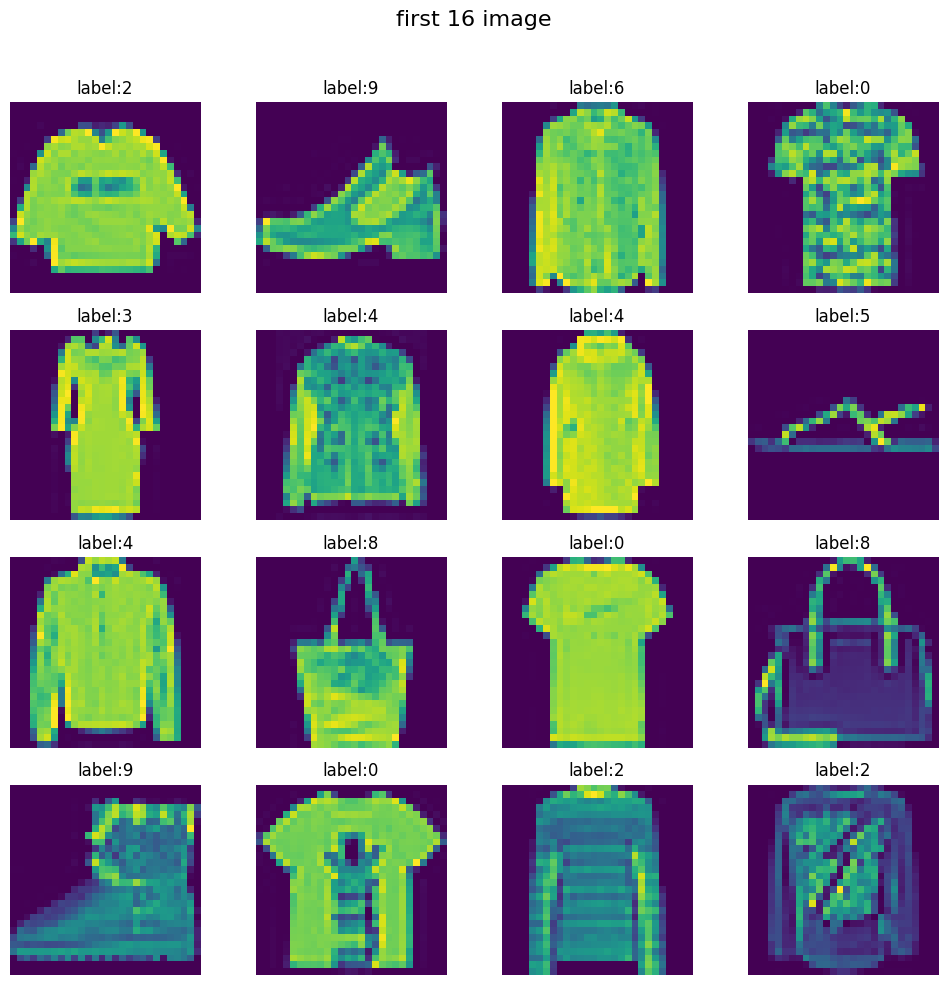

In [7]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('first 16 image',fontsize=16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"label:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
y

,label
0,2
1,9
2,6
3,0
4,3
...,...
59995,9
59996,1
59997,8
59998,8


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [13]:
# scale beacuse pixel avlue is lie between 0-255

X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
# custom dataset class
class CustomDataset(Dataset):

  def __init__(self,features,labels) :
    self.features = torch.tensor(features.values,dtype=torch.float32) # Convert DataFrame to numpy array
    self.labels = torch.tensor(labels.values,dtype=torch.long) # Convert Series to numpy array and fix typo

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [15]:
# create train_dataset object
train_dataset = CustomDataset(X_train,y_train)

In [16]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0235, 0.0824, 0.2157, 0.2824, 0.3451, 0.4235,
         0.1176, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.4118, 0.5569, 0.5569, 0.5686, 0.6118, 0.7686,
         0.5451, 0.5176, 0.5804, 0.6039, 0.6275, 0.6510, 0.6471, 0.6471, 0.3608,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.3843, 0.3333, 0.2784, 0.2824, 0.3804,
         0.3608, 0.4235, 0.5490, 0.5333, 0.4824, 0.4941, 0.4510, 0.5176, 0.5059,
         0.5059, 0.0000, 0.0

In [17]:
test_dataset = CustomDataset(X_test,y_test)

In [21]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)


In [36]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)


In [41]:
def objective(trial):
  num_hidden_layers = trial.suggest_int('num_hidden_layer',1,5)
  nueron_per_layer = trial.suggest_int('nueron_per_layer',8,128,step=8)
  epochs = trial.suggest_int('epoch',10,50,step=10)
  learning_rate = trial.suggest_float('learning_rate',1e-5,10e-1,log=True)
  dropout_rate = trial.suggest_float('dropout_rate',0.1,0.5,step=0.1)
  batch_size = trial.suggest_categorical('batch_size',[16,32,64,128])
  optimizer_name = trial.suggest_categorical('optimizer',['Adam','SGD','RMSprop'])
  weight_decay = trial.suggest_float('weight_decay',1e-5,1e-3,log=True)

  train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
  test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim,output_dim,num_hidden_layers,nueron_per_layer,dropout_rate)
  model.to(device)

  #param init


  #optimizer
  criterion = nn.CrossEntropyLoss()

  if optimizer_name=='Adam':
    optimizer = optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  elif optimizer_name=='SGD':
    optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  #train loop
  for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features,batch_labels in train_loader:

      #step 3 gpu
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

      #forawrd
      outputs = model(batch_features)
      # claculate
      loss = criterion(outputs,batch_labels)

      #back pass
      optimizer.zero_grad()#clear the gradient
      loss.backward()
      #update
      optimizer.step()

      total_epoch_loss += loss.item()

    avg_total = total_epoch_loss/len(train_loader)

    # model eval
    model.eval()
    # `import torch` is already present at the top of the notebook, removing redundant import.

    total = 0
    correct = 0
    accuracy_list=[]
    with torch.no_grad():
      for batch_features,batch_labels in test_loader:

        # move the data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        y_pred = model(batch_features)
        # Get the predicted class by finding the index with the maximum score
        predicted_classes = y_pred.argmax(dim=1)

        # Compare predicted classes with actual labels
        batch_accuracy = (predicted_classes == batch_labels).float().mean().item()
        accuracy_list.append(batch_accuracy)

    overall_accuracy = sum(accuracy_list)/len(accuracy_list)

    return overall_accuracy

In [38]:
#define nn class

!pip install optuna


In [39]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2026-07-20 02:37:15,935] A new study created in memory with name: no-name-75ce5dcd-89b8-45e7-b558-256585e534b7


In [45]:
study.optimize(objective,n_trials=50)

[I 2026-07-20 02:39:22,978] Trial 11 finished with value: 0.2738888888888889 and parameters: {'num_hidden_layer': 4, 'nueron_per_layer': 8, 'epoch': 10, 'learning_rate': 0.010602537902628212, 'dropout_rate': 0.5, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 0.00027948165894481537}. Best is trial 3 with value: 0.8431666666666666.
[I 2026-07-20 02:39:29,381] Trial 12 finished with value: 0.8397777777777777 and parameters: {'num_hidden_layer': 1, 'nueron_per_layer': 128, 'epoch': 30, 'learning_rate': 0.0014300067394819804, 'dropout_rate': 0.4, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 1.392311614527209e-05}. Best is trial 3 with value: 0.8431666666666666.
[I 2026-07-20 02:39:36,842] Trial 13 finished with value: 0.8434444444444444 and parameters: {'num_hidden_layer': 2, 'nueron_per_layer': 112, 'epoch': 30, 'learning_rate': 0.005243575934040834, 'dropout_rate': 0.1, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 4.3654379085260055e-05}. Best is trial 13 w

In [46]:
study.best_value

0.8532222222222222

In [ ]:
# try on train data
import torch

total = 0
correct = 0
accuracy_list=[]
with torch.no_grad():
  for batch_features,batch_labels in train_loader:

    # move the data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    y_pred = model(batch_features)
    # Get the predicted class by finding the index with the maximum score
    predicted_classes = y_pred.argmax(dim=1)

    # Compare predicted classes with actual labels
    batch_accuracy = (predicted_classes == batch_labels).float().mean().item()
    accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list)/len(accuracy_list)
print(f'accuracy:{overall_accuracy:.4f}')

In [ ]:
len(test_loader)